# notes
script:  parse_and_plot_FPLC.py

description:
    Load the FPLC CSV data in FPLC_data/file.csv, clean headers,
    parse numeric columns, and graph signals (UV, Conductivity, Conc B, etc).

requirements:
    pandas, matplotlib

# imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# filepath

In [2]:
__file__ = "20260311_ZD_TigE.csv"
# print(f"Current file: {__file__}")
DATA_DIR = Path(__file__).resolve().parent 
# print(f"Data directory: {DATA_DIR}")
CSV_FILE = DATA_DIR / "20260311_ZD_TigE.csv"
# print(f"Reading data from: {CSV_FILE}")

# read raw csv


In [ ]:
# The file has 2 rows to ignore at the top 
# then one header row, then the data starts at row 4 (0-indexed row 3)
uv_cond_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s+",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[0,1,3],  # only mL, mAU, mS/cm columns
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

injection_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s+",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[6],  # only injection column
    nrows=1,
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

fractions_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[8,9],  # mL and fraction# 
    engine="python",
    encoding="utf-16",
    # converters={1: int},
    na_values=["", '""'],
)
fractions_raw["Fraction"] = fractions_raw["Fraction"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
# print("Columns:", uv_cond_raw.columns.tolist())

# convert to numeric
uv_cond_df = uv_cond_raw.apply(pd.to_numeric, errors="coerce")
injection_df = injection_raw.apply(pd.to_numeric, errors="coerce")
fractions_df = fractions_raw.apply(pd.to_numeric, errors="coerce")

# print("Data frame shape:", df.shape)
# print("sample data:")
# print(uv_cond_df.head())
# print(injection_df)
# print(fractions_raw)
# print(fractions_df.head())

sample data:
         ml       mAU      mS/cm
0 -0.451822  0.000000  36.964851
1 -0.432608 -0.005409  36.971283
2 -0.413395 -0.023852  36.983768
3 -0.394181 -0.034320  36.982605
4 -0.374968 -0.033144  36.960472
       ml.3
0  0.009303
        ml.4  Fraction
0  87.911627       2.0
1  89.910567       3.0
2  91.912108       4.0
3  93.912260       5.0
4  95.912688       6.0


# plot

Saved plot: /Users/zachdinardo/Desktop/School/Penn/BookerLab/BookerLabZD-code/FPLC_data/20260311_ZD_TigE_FPLC_UV_and_cond


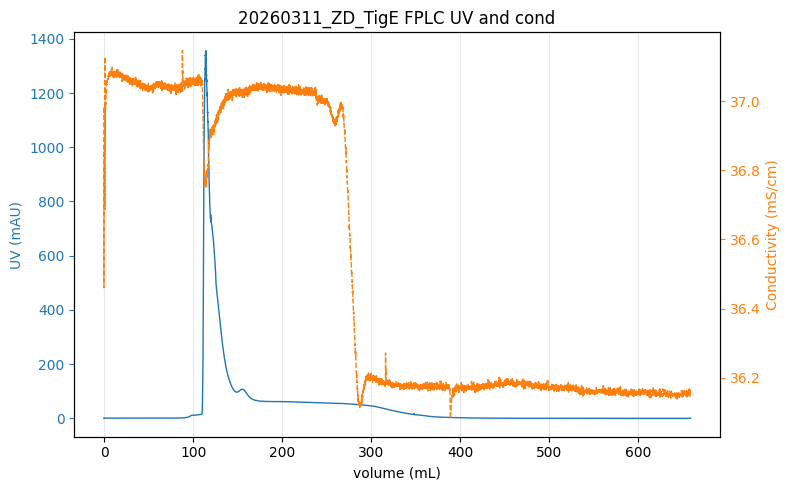

In [101]:
# plot UV (and optionally conductance) vs mL 
show_cond = 1 
x = uv_cond_df["ml"]
y_uv = uv_cond_df["mAU"]
y_cond = uv_cond_df["mS/cm"] if "mS/cm" in uv_cond_df.columns else None

fig, ax1 = plt.subplots(figsize=(16*0.5, 10*0.5))

color_uv = "tab:blue"
ax1.set_xlabel("volume (mL)")
ax1.set_ylabel("UV (mAU)", color=color_uv)
ax1.plot(x, y_uv, color=color_uv, linewidth=1)
ax1.tick_params(axis="y", colors=color_uv)

if show_cond == True:
    ax2 = ax1.twinx()
    color_cond = "tab:orange"
    ax2.set_ylabel("Conductivity (mS/cm)", color=color_cond)
    ax2.plot(x, y_cond, color=color_cond, linewidth=1, linestyle="--")
    ax2.tick_params(axis="y", colors=color_cond)

# Save and show
plt.title(f"{__file__[:-4]} FPLC UV{" and cond" if show_cond==1 else ""}")
ax1.grid(True, axis="x", alpha=0.3)
fig.tight_layout()

out_png = DATA_DIR / f"{__file__[:-4]}_FPLC_UV{"_and_cond" if show_cond==1 else ""}"
fig.savefig(out_png, dpi=1500)
print("Saved plot:", out_png)

plt.show()

Saved plot: /Users/zachdinardo/Desktop/School/Penn/BookerLab/BookerLabZD-code/FPLC_data/20260311_ZD_TigE_FPLC_UV_and_cond_zoomed


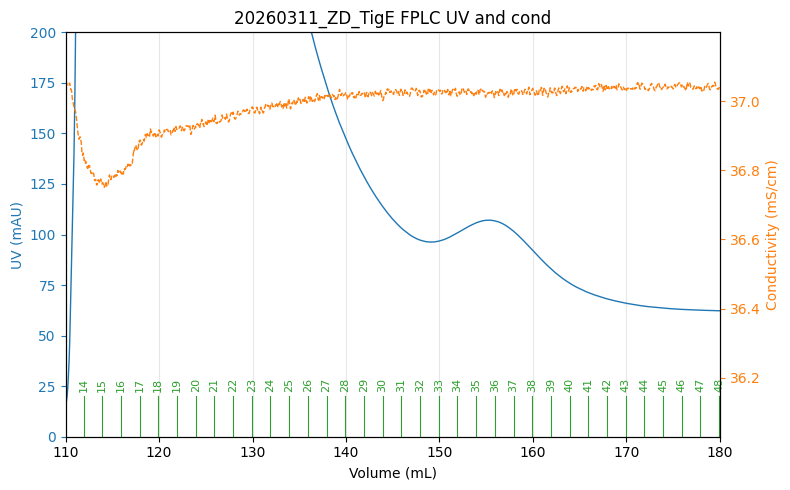

In [102]:
# zoom in on peak of interest with fraction collection 
show_cond = 1
ml_start = 110
ml_end = 180
mau_height = 200

x = uv_cond_df["ml"]
y_uv = uv_cond_df["mAU"]
y_cond = uv_cond_df["mS/cm"] if "mS/cm" in uv_cond_df.columns else None

fig, ax1 = plt.subplots(figsize=(16*0.5, 10*0.5))

color_uv = "tab:blue"
ax1.set_xlabel("Volume (mL)")
ax1.set_ylabel("UV (mAU)", color=color_uv)
ax1.set_xlim(ml_start,ml_end)
ax1.set_ylim(0,mau_height)
ax1.plot(x, y_uv, color=color_uv, linewidth=1)
ax1.tick_params(axis="y", colors=color_uv)

if show_cond == True:
    ax2 = ax1.twinx()
    color_cond = "tab:orange"
    ax2.set_ylabel("Conductivity (mS/cm)", color=color_cond)
    ax2.plot(x, y_cond, color=color_cond, linewidth=1, linestyle="--")
    ax2.tick_params(axis="y", colors=color_cond)

for i, (ml, frac) in enumerate(zip(fractions_df["ml.4"], fractions_df["Fraction"]), start=1):
    if ml > ml_start and ml < ml_end:
        ax1.axvline(x=ml, color="tab:green", linestyle="-", linewidth=0.8, ymin=0, ymax=0.1)
        ax1.text(ml, ax1.get_ylim()[1]*0.11, f"{frac:.0f}", rotation=90,
                va="bottom", ha="center", fontsize=8, color="tab:green")

# Save and show
plt.title(f"{__file__[:-4]} FPLC UV{" and cond" if show_cond==1 else ""}")
ax1.grid(True, axis="x", alpha=0.3)
fig.tight_layout()

out_png = DATA_DIR / f"{__file__[:-4]}_FPLC_UV{"_and_cond" if show_cond==1 else ""}_zoomed"
fig.savefig(out_png, dpi=1500)
print("Saved plot:", out_png)

plt.show()